In [22]:

import hbsir
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


In [23]:
import yaml

def extract_table_names(yaml_file_path):
    with open(yaml_file_path, 'r', encoding='utf-8') as file:
        schema = yaml.safe_load(file)

    table_names = set()

    # Extract top-level tables (direct keys)
    for key in schema.keys():
        if isinstance(schema[key], dict) and 'instructions' in schema[key]:
            table_names.add(key)

    # Extract tables from table_list sections
    for section in schema.values():
        if isinstance(section, dict) and 'table_list' in section:
            table_list = section['table_list']
            if isinstance(table_list, dict):
                for tables in table_list.values():
                    if isinstance(tables, list):
                        table_names.update(tables)
                    elif isinstance(tables, str):
                        table_names.add(tables)
            elif isinstance(table_list, list):
                table_names.update(table_list)

    # Remove None if present and sort alphabetically
    table_names.discard(None)
    return sorted(table_names)

# Usage example
yaml_file = r'.\schema.yaml'
tables = extract_table_names(yaml_file)
print(tables)

['Administrative_Divisions', 'Cash_Incomes', 'Equivalence_Scale', 'Expenditures', 'Imputed_Rent', 'Income_Breakdown', 'Members_Income_Breakdown', 'Members_Total_Income', 'NonCash_Incomes', 'NonCash_Incomes_Excluding_Imputed_Rent', 'Number_of_Members', 'Original_Expenditures', 'Original_Outlays', 'Outlays', 'Season', 'Total_Expenditure', 'Total_Income', 'Total_Outlay', 'Weight', '_long_other_income', 'census_month', 'cloth', 'communication', 'durable', 'education', 'employment_income', 'entertainment', 'external.hbsir_weights', 'food', 'furniture', 'home', 'hotel', 'house_specifications', 'household_information', 'investment', 'medical', 'members_properties', 'miscellaneous', 'old_rural_house_specifications', 'old_urban_house_specifications', 'other_income', 'private_employment_income', 'public_employment_income', 'self_employed_income', 'subsidy', 'tobacco', 'transportation']


In [24]:
# import os
# lyear = 1393
# hbsir.setup(years=f"{lyear}",method="download_cleaned",download_source="mirror")
# years = [lyear]
# tables = extract_table_names(yaml_file)
#
# for year in years:
#     for t in tables:
#         try:
#             print("Loading year", year)
#             table = hbsir.load_table(t, years=year)
#             directory_path = rf'D:\regres project\csvs data\{t}\{year}'
#             os.makedirs(directory_path, exist_ok=True)
#             output = os.path.join(directory_path, f'{t}_{year}.csv')
#             table.to_csv(output, index=False)
#             print("Table", year, "done!")
#         except Exception as e:
#             print(f"Error processing year {year}: {e}")
#             continue

In [25]:
def csvfind(tableName , year ):
    path = "D:\\regres project\\csvs data\\" + tableName +"\\"+str(year)+"\\"+tableName+"_"+str(year)+".csv"
    return  pd.read_csv(path)

In [26]:
expenditures_95 = csvfind(tableName="Expenditures", year=1395)

In [27]:

expenditures_95 = hbsir.add_attribute(table=expenditures_95, name='Province',year_col="Year" ,id_col="ID")
expenditures_95 = hbsir.add_attribute(table=expenditures_95, name="Urban_Rural",year_col="Year" ,id_col="ID")
expenditures_95 = hbsir.add_attribute(table=expenditures_95, name="County",year_col="Year" ,id_col="ID")


In [28]:
members_properties_95 = csvfind(tableName="members_properties", year=1395)
employment_income_95 = csvfind("employment_income",1395)

In [29]:
head_edu = members_properties_95[members_properties_95["Member_Number"] == 1][["ID", "Education_Level"]]
hh_income = employment_income_95.groupby("ID")["Annual_Continuous_Income"].sum().reset_index()
hh_income.rename(columns={"Annual_Continuous_Income": "Household_Income"}, inplace=True)

In [30]:
merged = pd.merge(hh_income, head_edu, on="ID")
merged = merged.where(pd.notnull(merged), "None")
print(merged.head())


            ID  Household_Income       Education_Level
0  10001000120        18000000.0                  None
1  10001000123        45000000.0                  None
2  10001000135       135000000.0                  None
3  10001000223       177360012.0        Pre_University
4  10001000320       271620000.0  Short_Cycle_Tertiary


In [31]:
mean_income_by_edu = merged.groupby("Education_Level")["Household_Income"].mean().sort_values(ascending=False)
print(mean_income_by_edu)


Education_Level
Doctoral                4.246935e+08
Masters                 2.928560e+08
Bachelors               2.330590e+08
Short_Cycle_Tertiary    1.882370e+08
Pre_University          1.459223e+08
Higher_Secondary        1.150528e+08
Lower_Secondary         1.144765e+08
Primary                 1.039657e+08
Unofficial              9.524174e+07
None                    9.478115e+07
Name: Household_Income, dtype: float64


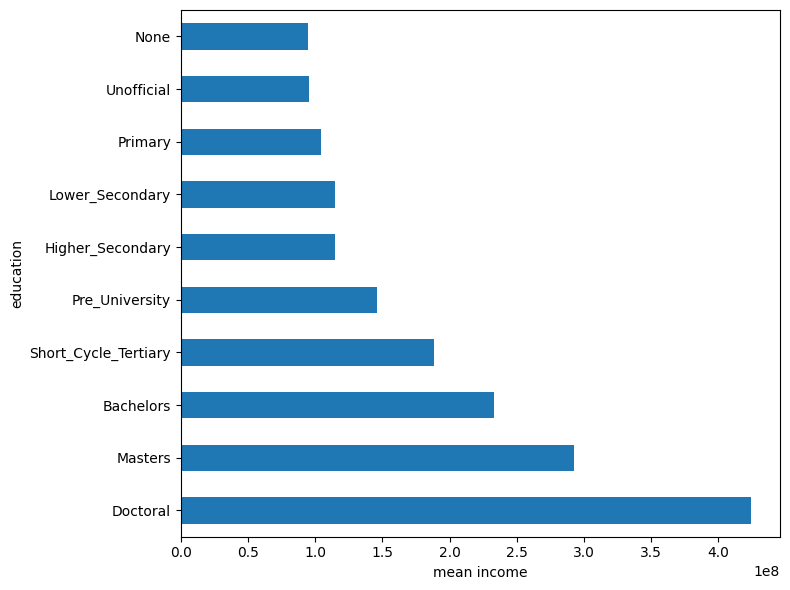

In [32]:
import matplotlib.pyplot as plt

mean_income_by_edu.plot(kind="barh", figsize=(8, 6))
plt.xlabel("mean income")
plt.ylabel("education")
plt.tight_layout()
plt.show()

In [33]:
from sklearn.linear_model import LinearRegression


def regression_with_interactions_sklearn(df, independent_vars, target_var):
    # انتخاب داده‌ها
    X = df[independent_vars]
    y = df[target_var]

    # تبدیل متغیرهای رشته‌ای به عددی
    X = pd.get_dummies(X, drop_first=True)

    # ساخت متغیرهای تعاملی
    interaction_terms = []
    columns = list(X.columns)

    for var1, var2 in combinations(columns, 2):
        interaction_name = f'{var1}:{var2}'
        interaction_terms.append(X[var1] * X[var2])
        interaction_terms[-1].name = interaction_name

    # اضافه کردن متغیرهای تعاملی به X
    X = pd.concat([X] + interaction_terms, axis=1)

    # اضافه کردن یک ستون ثابت (intercept) برای مدل
    X['constant'] = 1

    # ساخت مدل رگرسیونی
    model = LinearRegression()

    # برازش مدل
    model.fit(X, y)

    # نمایش ضرایب
    coef_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
    return coef_df

# فرض کنید df دیتافریم شماست که شامل متغیرهای X1, X2, X3 و y است
# independent_vars = ['X1', 'X2', 'X3']
# # لیست ستون‌ها برای متغیرهای ورودی
# target_var = 'y'  # اسم ستون هدف
# df = pd.DataFrame()
# result = regression_with_interactions_sklearn(df, independent_vars, target_var)
# print(result)

In [34]:
import statsmodels.api as sm
from itertools import combinations

def regression_with_interactions(df, independent_vars, target_var):
    # انتخاب داده‌ها
    X = df[independent_vars]
    y = df[target_var]

    # تبدیل متغیرهای رشته‌ای به عددی
    X = pd.get_dummies(X, drop_first=True)

    # ساختن متغیرهای تعاملی
    interaction_terms = []
    columns = list(X.columns)

    for var1, var2 in combinations(columns, 2):
        interaction_name = f'{var1}_&_{var2}'
        interaction_terms.append(X[var1] * X[var2])
        interaction_terms[-1].name = interaction_name

    # اضافه کردن متغیرهای تعاملی
    X = pd.concat([X] + interaction_terms, axis=1)

    # افزودن ستون ثابت
    X = sm.add_constant(X)

    # برازش مدل
    model = sm.OLS(y, X).fit()

    return model

In [35]:
merged = pd.merge(expenditures_95, members_properties_95, on="ID")


In [36]:
table_1395 = expenditures_95
# table_1395 = hbsir.add_attribute(table=table_1395, name='Province',year_col="Year" ,id_col="ID")
# table_1395 = hbsir.add_attribute(table=table_1395, name="Urban_Rural",year_col="Year" ,id_col="ID")
# table_1395 = hbsir.add_attribute(table=table_1395, name="County",year_col="Year" ,id_col="ID")
hhinc_1395 = csvfind(tableName="employment_income", year=1395)
members_1395 = csvfind("members_properties",1395)

C:\Users\Pc-Tech\AppData\Local\Temp\ipykernel_19252\3727247502.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_income_1395 = df_1395.groupby("Education_Level")["Annual_Continuous_Income"].mean().reindex(valid_levels)


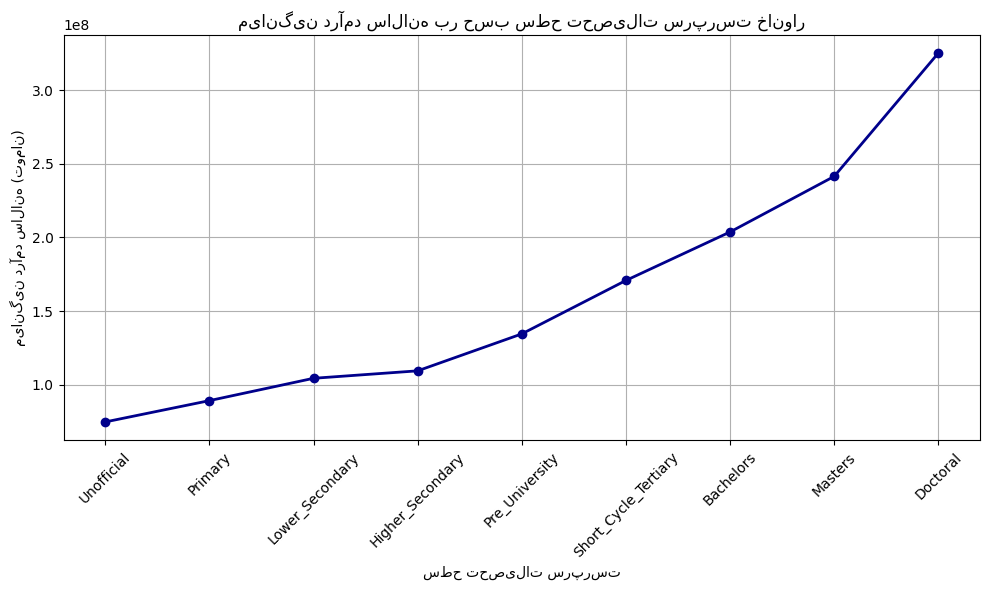

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# لیست مرتب‌شده سطح تحصیلات
valid_levels = [
    "Unofficial",
    "Primary",
    "Lower_Secondary",
    "Higher_Secondary",
    "Pre_University",
    "Short_Cycle_Tertiary",
    "Bachelors",
    "Masters",
    "Doctoral"
]

# فیلتر فقط سرپرست‌ها با سطح تحصیلات معتبر
df_1395 = members_1395[
    (members_1395["Member_Number"] == 1) & (members_1395["Education_Level"].isin(valid_levels))].copy()

# تبدیل به نوع مرتب Categorical
df_1395["Education_Level"] = pd.Categorical(df_1395["Education_Level"], categories=valid_levels, ordered=True)

# اضافه کردن درآمد سرپرست‌ها از hhinc
df_1395 = df_1395.merge(
    hhinc_1395[hhinc_1395["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
    on="ID",
    how="left"
)

# حذف ردیف‌هایی که درآمد ندارن
df_1395 = df_1395.dropna(subset=["Annual_Continuous_Income"])

# محاسبه میانگین درآمد برای هر سطح تحصیل
mean_income_1395 = df_1395.groupby("Education_Level")["Annual_Continuous_Income"].mean().reindex(valid_levels)

# 📈 رسم نمودار
plt.figure(figsize=(10, 6))
plt.plot(mean_income_1395.index, mean_income_1395.values, marker='o', color='darkblue', linewidth=2)
plt.xlabel("سطح تحصیلات سرپرست")
plt.ylabel("میانگین درآمد سالانه (تومان)")
plt.title("میانگین درآمد سالانه بر حسب سطح تحصیلات سرپرست خانوار")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [38]:
def uploadingData(year):
    table = csvfind("Expenditures", year=year)
    table = hbsir.add_attribute(table=table, name='Province', year_col="Year", id_col="ID")
    table = hbsir.add_attribute(table=table, name="Urban_Rural", year_col="Year", id_col="ID")
    table = hbsir.add_attribute(table=table, name="County", year_col="Year", id_col="ID")
    hhinc = csvfind("employment_income", year=year)
    members = csvfind("members_properties", year=year)
    return table, hhinc, members
def proccessData(members,hhinc):
    # ---------- پردازش ----------
    df = members[(members["Member_Number"] == 1) &
                 (members["Education_Level"].isin(valid_levels))].copy()
    df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)

    df = df.merge(
        hhinc[hhinc["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
        on="ID", how="left"
    )
    return df
edu_map = {
    "Unofficial": 0,
    "Primary": 5,
    "Lower_Secondary": 8,
    "Higher_Secondary": 12,
    "Pre_University": 13,
    "Short_Cycle_Tertiary": 14,
    "Bachelors": 16,
    "Masters": 18,
    "Doctoral": 22
}

In [39]:
# tables=[]
# for year in range(1395, 1402):
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # ---------- بارگذاری داده‌ها ----------
#         table, hhinc, members = uploadingData(year)
#         df = proccessData(members, hhinc)
#         urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
#         df = df.merge(urban_rural, on="ID", how="left")
#
#         df = df.dropna(subset=["Annual_Continuous_Income"])
#         df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)
#
#         # ---------- مدل ----------
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # ---------- نمودار ----------
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Urban": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             subset = plot_df[plot_df["Urban"] == u]
#             axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
#             axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [40]:
# import hbsir
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np
# import statsmodels.formula.api as smf
#
# valid_levels = [
#     "Unofficial", "Primary", "Lower_Secondary", "Higher_Secondary",
#     "Pre_University", "Short_Cycle_Tertiary", "Bachelors", "Masters", "Doctoral"
# ]
#
# edu_map = {
#     "Unofficial": 0, "Primary": 5, "Lower_Secondary": 8, "Higher_Secondary": 12,
#     "Pre_University": 13, "Short_Cycle_Tertiary": 14, "Bachelors": 16,
#     "Masters": 18, "Doctoral": 22
# }
#
# for year in range(1396, 1402):
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # --- بارگذاری داده‌ها ---
#         table, hhinc, members = uploadingData(year)
#         df = proccessData(members, hhinc)
#
#         # Add urban/rural
#         urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
#         df = df.merge(urban_rural, on="ID", how="left")
#
#         # Remove rows without income
#         df = df.dropna(subset=["Annual_Continuous_Income"])
#
#         # Convert Urban_Rural to 0 and 1
#         df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)
#
#         # --- Modeling ---
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#         #
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # --- Prediction data ---
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Urban": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         # --- Plotting ---
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#
#         # Without interaction + actual points
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             # Regression line
#             subset_line = plot_df[plot_df["Urban"] == u]
#             axes[0].plot(subset_line["Years_Edu"], subset_line["pred_no_inter"], color=color, label=label)
#
#             # Actual points
#             subset_points = df[df["Urban"] == u]
#             axes[0].scatter(subset_points["Years_Edu"], subset_points["Annual_Continuous_Income"],
#                             color=color, alpha=0.5, s=20)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         # With interaction + actual points
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             subset_line = plot_df[plot_df["Urban"] == u]
#             axes[1].plot(subset_line["Years_Edu"], subset_line["pred_inter"], color=color, label=label)
#
#             subset_points = df[df["Urban"] == u]
#             axes[1].scatter(subset_points["Years_Edu"], subset_points["Annual_Continuous_Income"],
#                             color=color, alpha=0.5, s=20)
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [41]:
# for year in range(1395, 1402):
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # ---------- بارگذاری داده‌ها ----------
#         table, hhinc, members = uploadingData(year)
#         df = proccessData(members, hhinc)
#
#         # Gender column: Assuming Gender column exists in members
#         # Male -> 1, Female -> 0
#         df["Gender_Binary"] = df["Sex"].apply(lambda x: 1 if str(x).lower() == "male" else 0)
#
#         # Remove rows without income or gender
#         df = df.dropna(subset=["Annual_Continuous_Income", "Gender_Binary"])
#
#         # ---------- Model ----------
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Gender_Binary", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Gender_Binary", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#         #
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # ---------- Plot ----------
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Gender_Binary": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#         for g, color, label in [(0, "purple", "Female"), (1, "green", "Male")]:
#             subset = plot_df[plot_df["Gender_Binary"] == g]
#             axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
#             axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [42]:
# ## spouse income
# for year in range(1395, 1402):
#
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # ---------- بارگذاری داده‌ها ----------
#         table, hhinc, members = uploadingData(year)
#         df = members[(members["Relationship"] == "Spouse") &
#                      (members["Education_Level"].isin(valid_levels))].copy()
#         df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)
#         df = df.merge(
#             hhinc[["ID", "Annual_Continuous_Income"]],
#             on="ID", how="left"
#         )
#         urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
#         df = df.merge(urban_rural, on="ID", how="left")
#
#         df = df.dropna(subset=["Annual_Continuous_Income"])
#         df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)
#
#         # ---------- مدل ----------
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # ---------- نمودار ----------
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Urban": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             subset = plot_df[plot_df["Urban"] == u]
#             axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
#             axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [52]:
# ## family income
# for year in range(1395, 1402):
#
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # ---------- بارگذاری داده‌ها ----------
#         table, hhinc, members = uploadingData(year)
#         df = pd.merge(members, hhinc, on=["ID","Member_Number"], how="left")
#
#
#
#
#         df = members[(members["Education_Level"].isin(valid_levels))].copy()
#         df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)
#
#         df = df.merge(
#             hhinc[["ID","Member_Number", "Annual_Continuous_Income"]],
#            on=["ID","Member_Number"], how="left"
#         )
#         df = df.dropna(subset=["Annual_Continuous_Income" , "Education_Level"])
#
#         result = df.groupby('ID').agg({
#         'Annual_Continuous_Income': 'sum' ,"Years_Edu":"max"}).reset_index()
#
#         urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
#         result = result.merge(urban_rural, on="ID", how="left")
#         df = result
#         df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)
#
#         # ---------- مدل ----------
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # ---------- نمودار ----------
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Urban": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             subset = plot_df[plot_df["Urban"] == u]
#             axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
#             axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

---------------1395---------------
---------------food-----------------


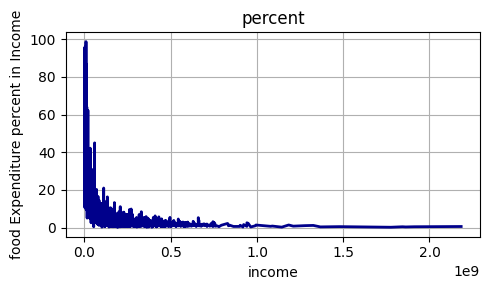

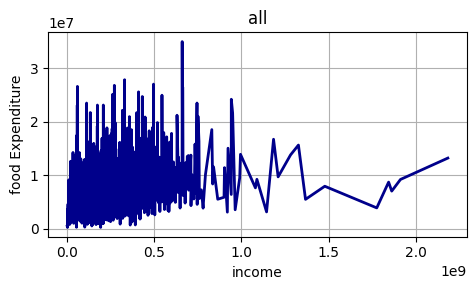

---------------tobacco-----------------


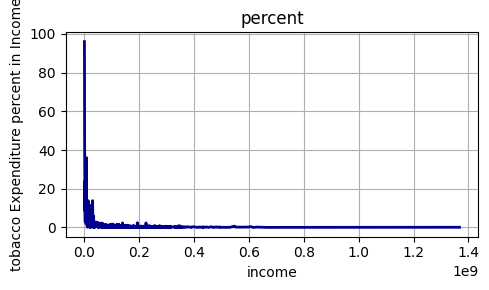

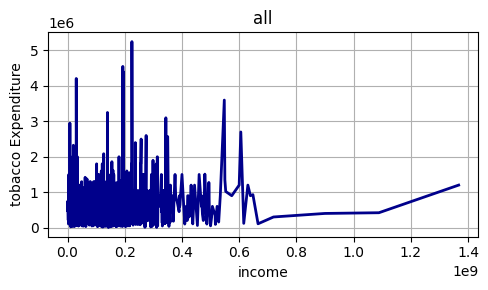

---------------cloth-----------------


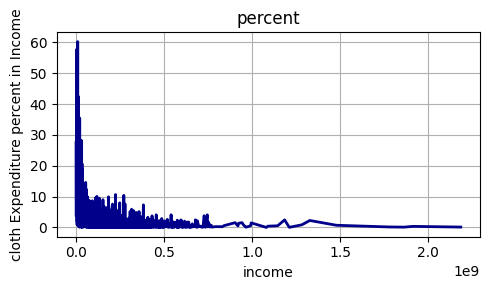

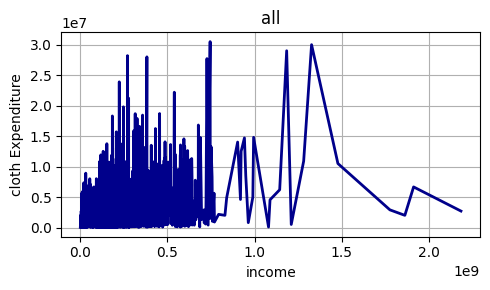

---------------home-----------------


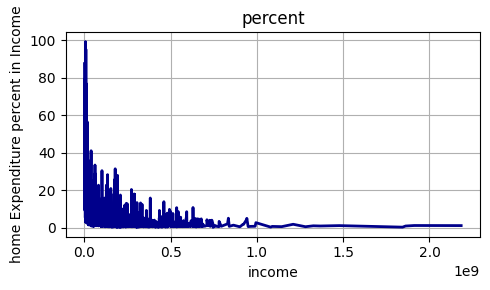

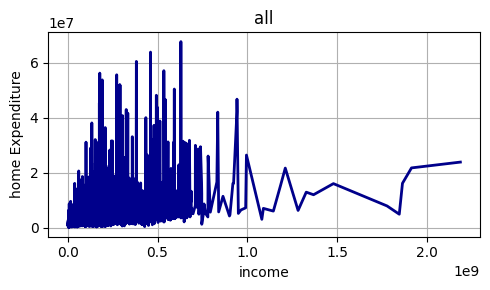

---------------furniture-----------------


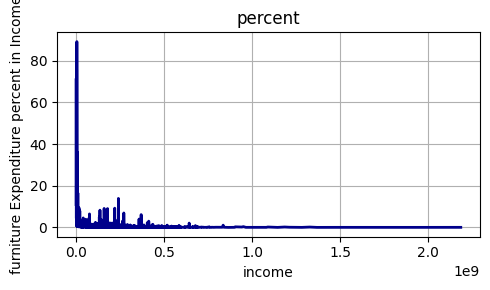

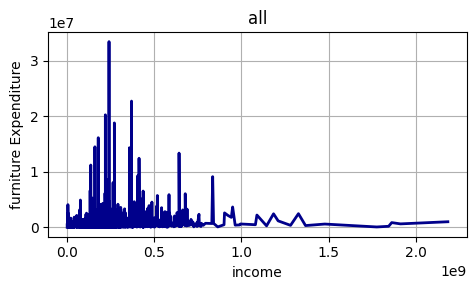

---------------medical-----------------


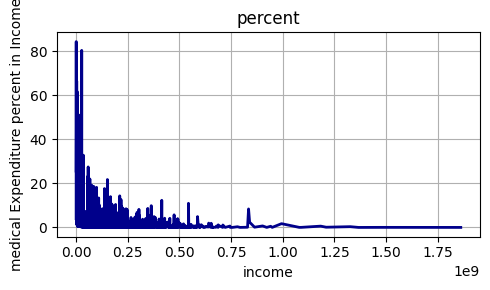

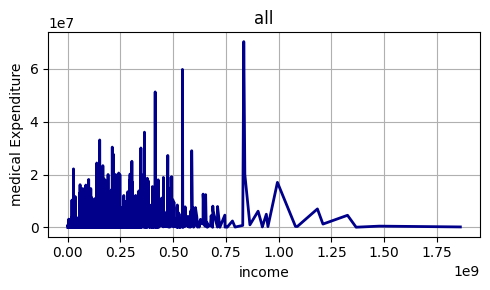

---------------transportation-----------------


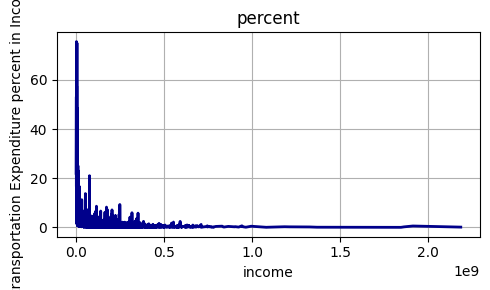

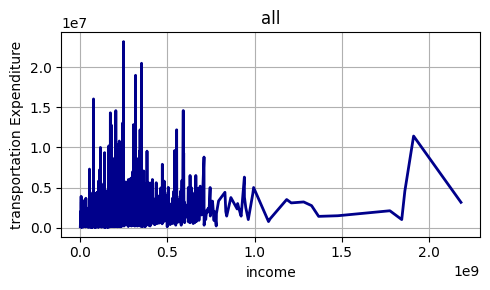

---------------communication-----------------


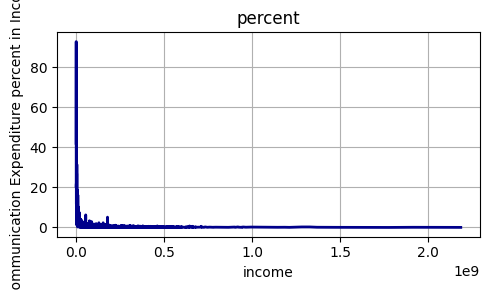

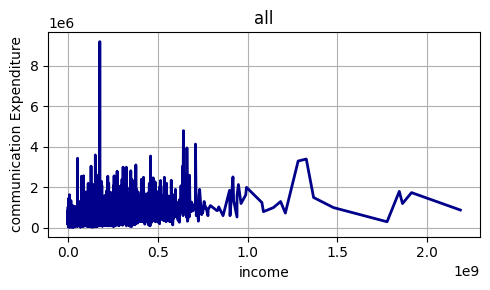

---------------entertainment-----------------


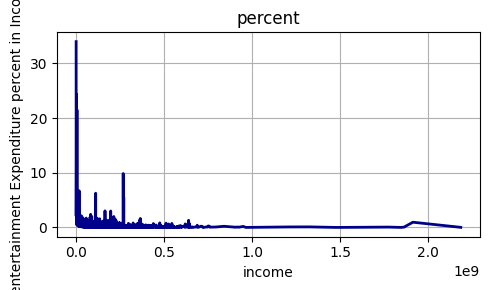

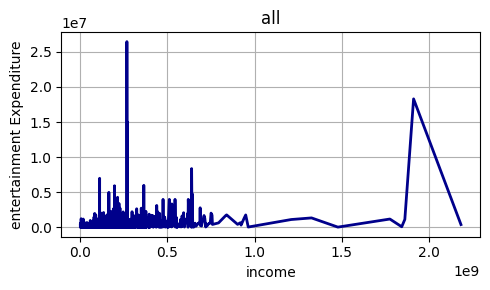

---------------hotel-----------------


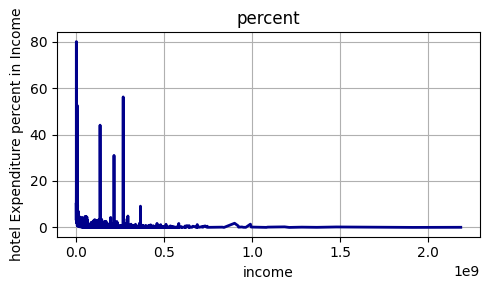

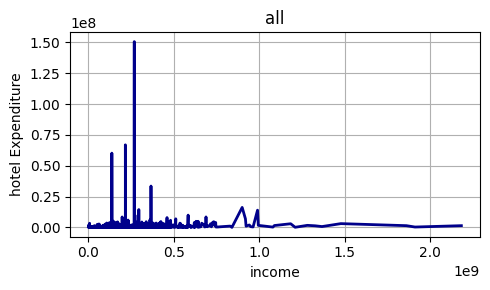

---------------miscellaneous-----------------


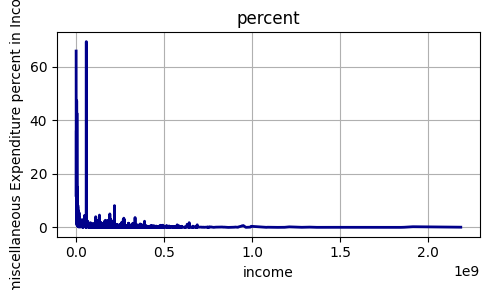

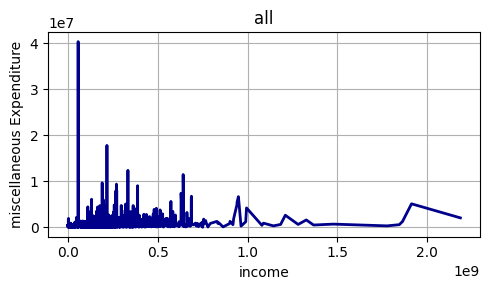

---------------durable-----------------


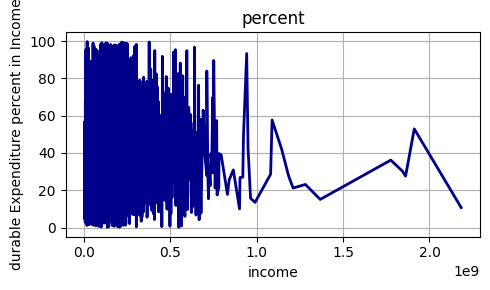

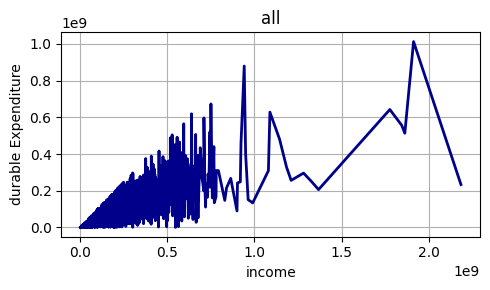

---------------investment-----------------


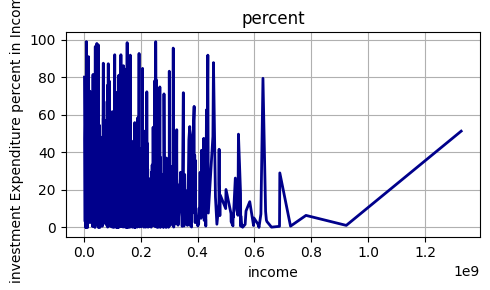

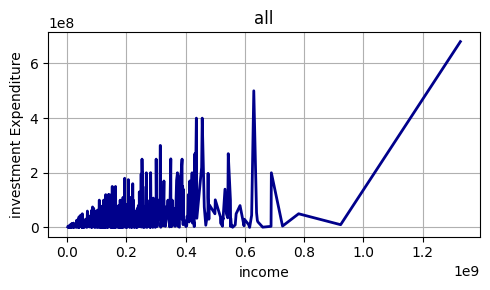

---------------1396---------------
---------------food-----------------


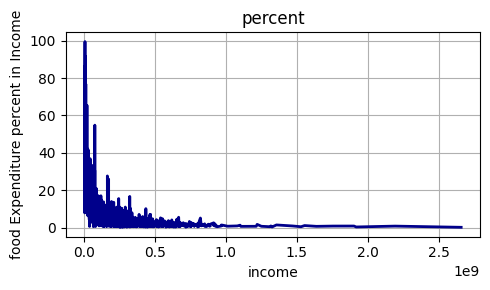

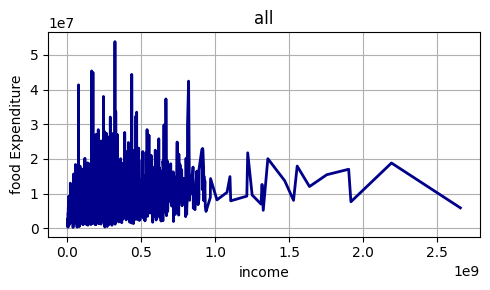

---------------tobacco-----------------


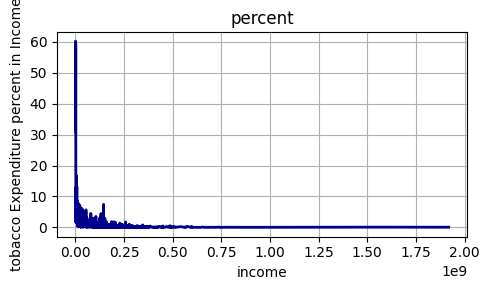

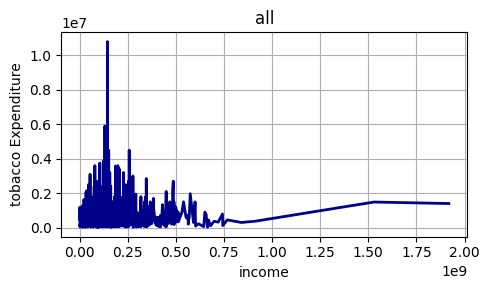

---------------cloth-----------------


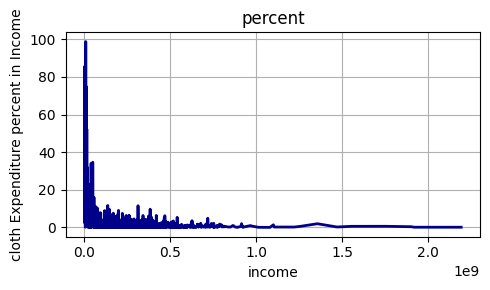

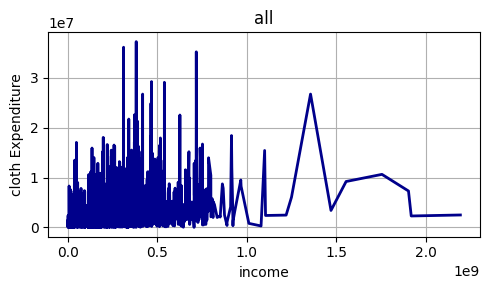

---------------home-----------------


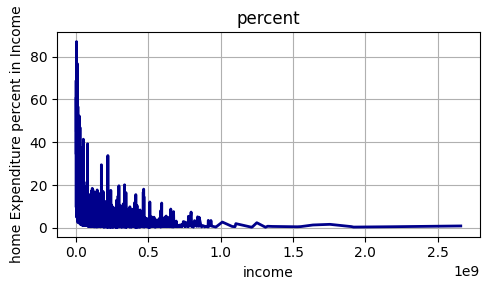

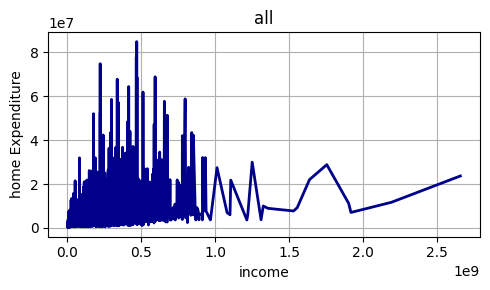

---------------furniture-----------------


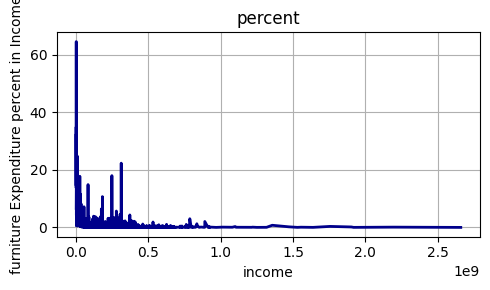

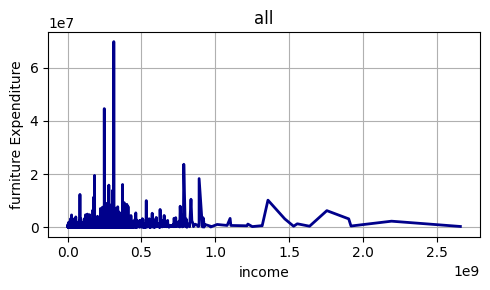

---------------medical-----------------


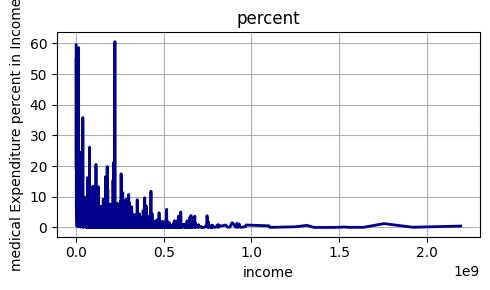

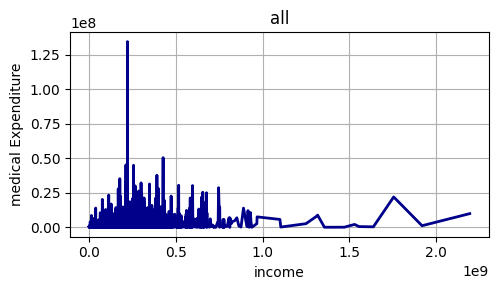

---------------transportation-----------------


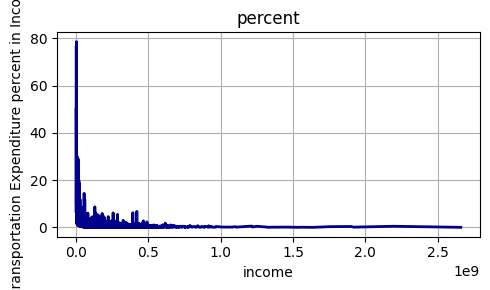

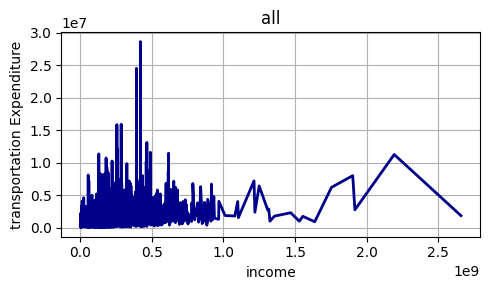

---------------communication-----------------


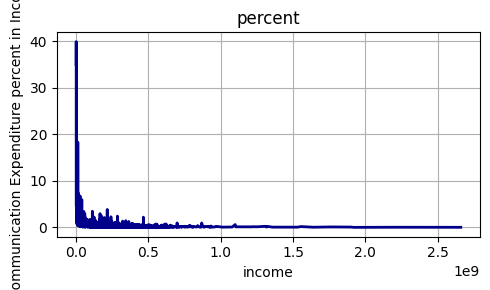

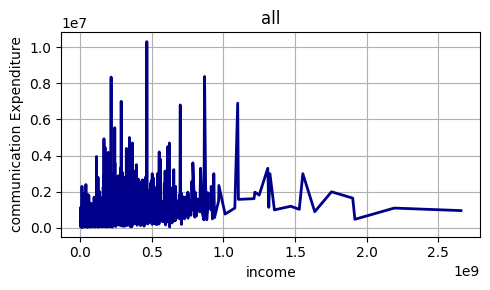

---------------entertainment-----------------


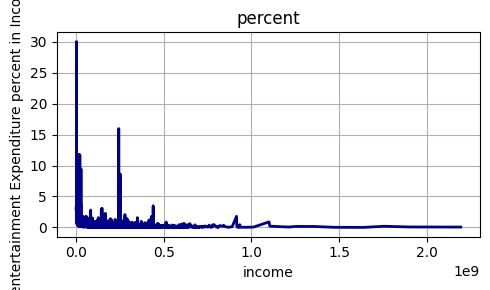

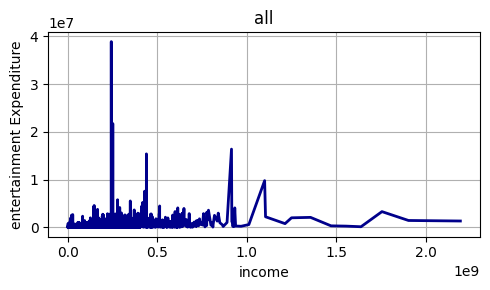

---------------hotel-----------------


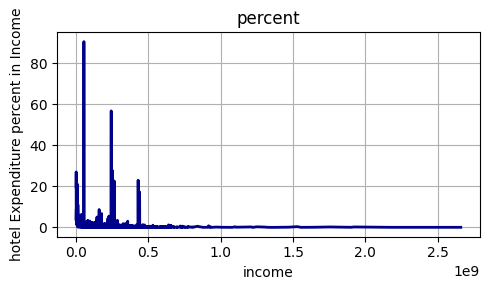

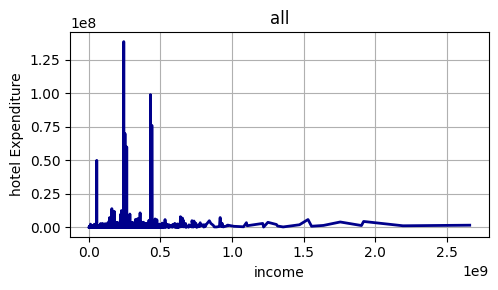

---------------miscellaneous-----------------


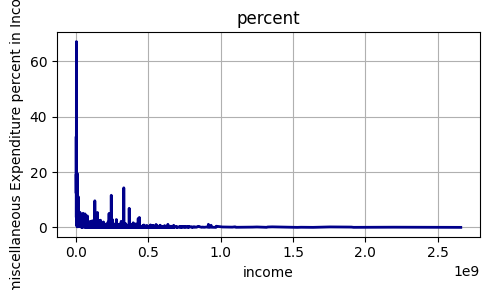

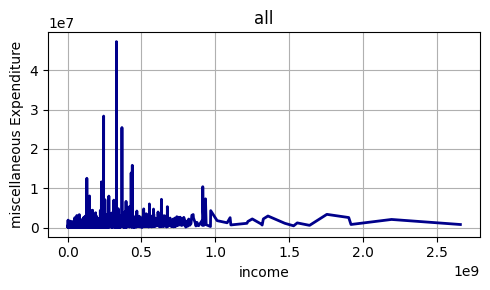

---------------durable-----------------


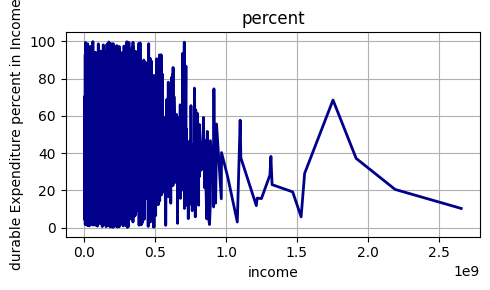

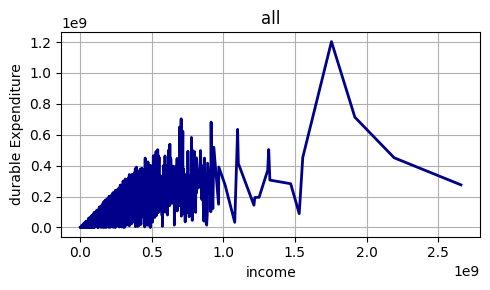

---------------investment-----------------


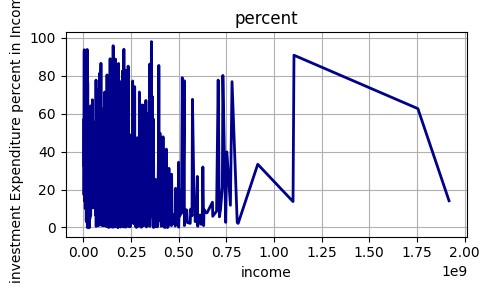

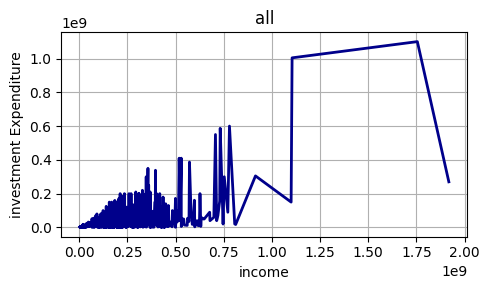

---------------1397---------------
---------------food-----------------


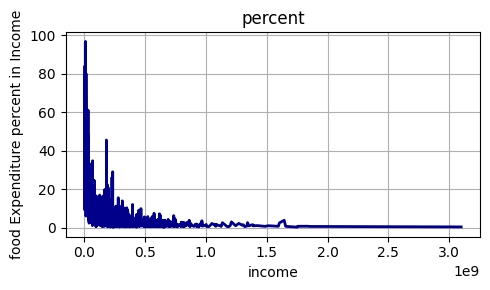

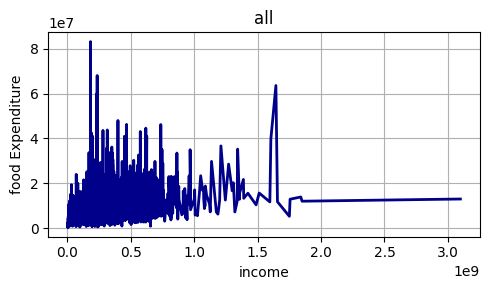

---------------tobacco-----------------


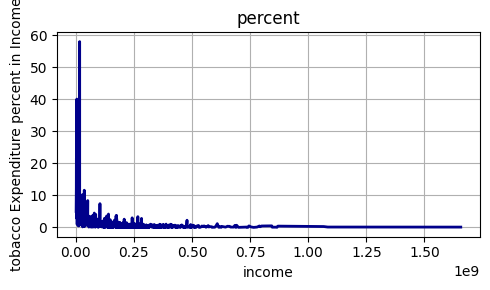

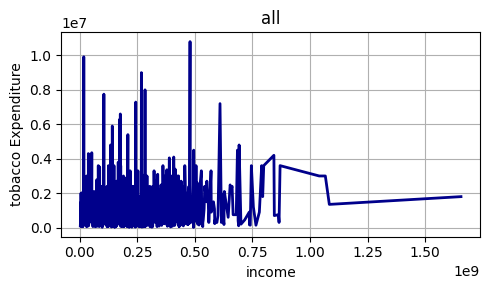

---------------cloth-----------------


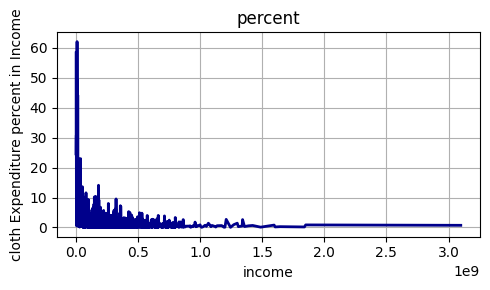

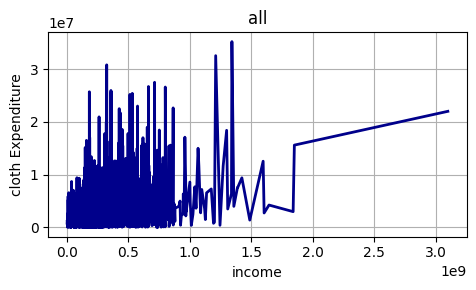

---------------home-----------------


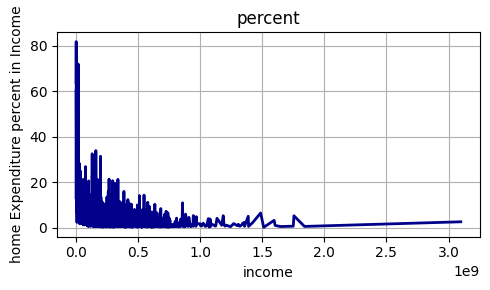

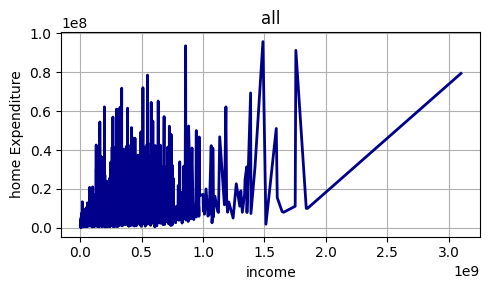

---------------furniture-----------------


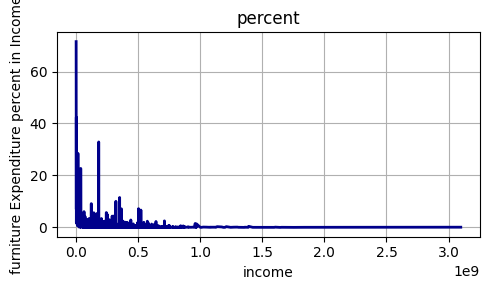

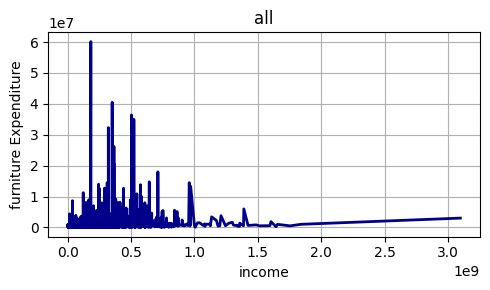

---------------medical-----------------


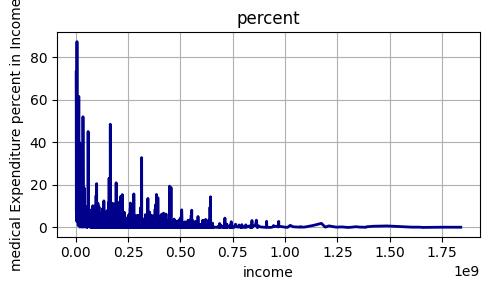

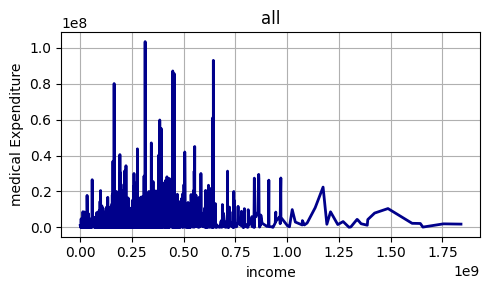

---------------transportation-----------------


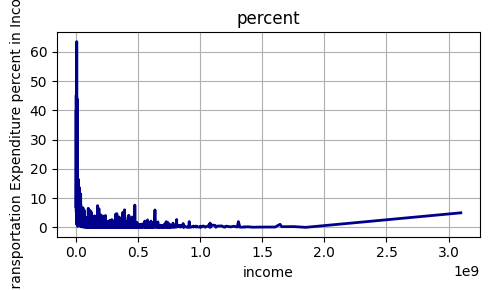

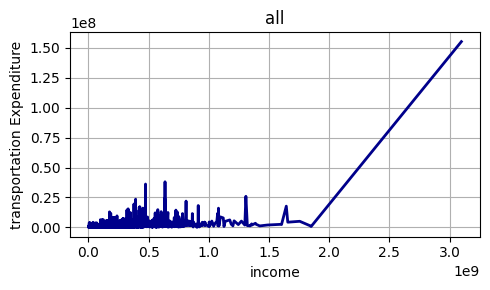

---------------communication-----------------


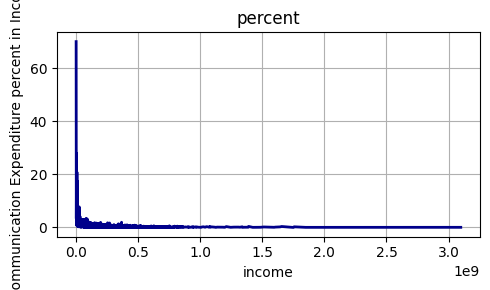

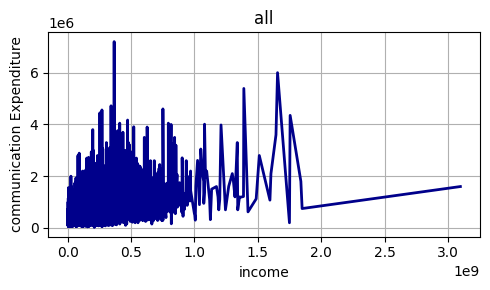

---------------entertainment-----------------


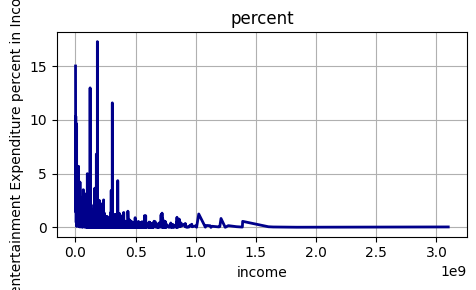

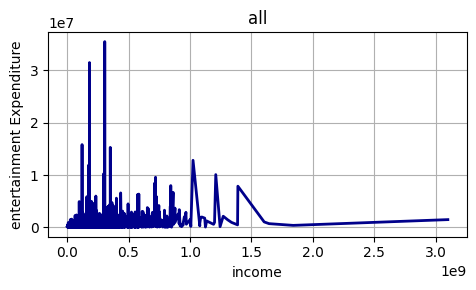

---------------hotel-----------------


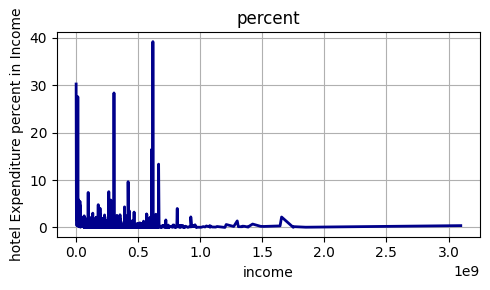

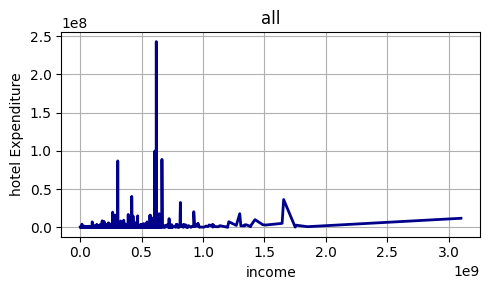

---------------miscellaneous-----------------


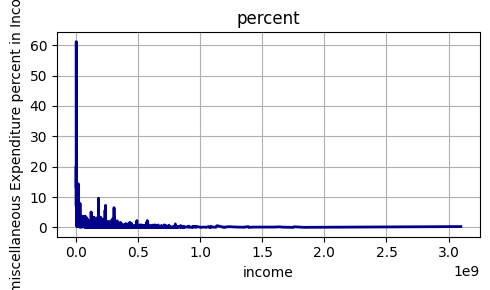

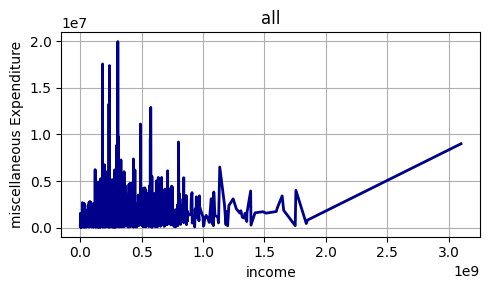

---------------durable-----------------


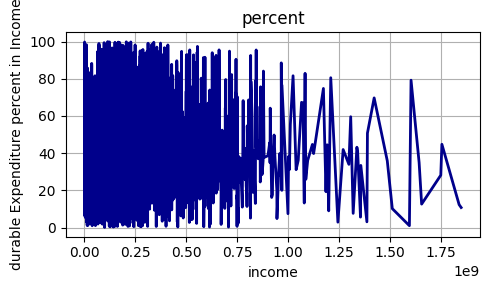

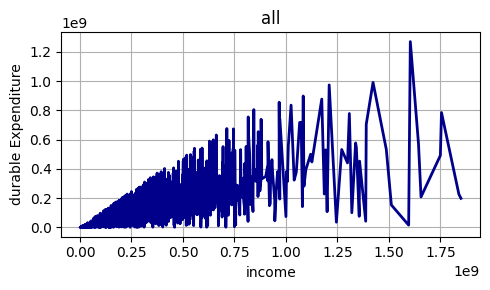

---------------investment-----------------


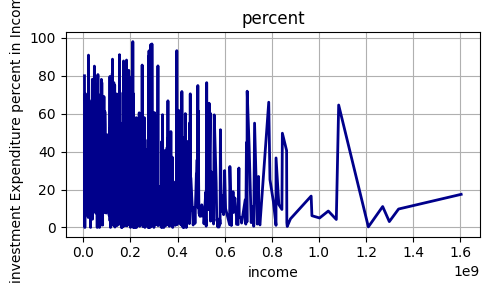

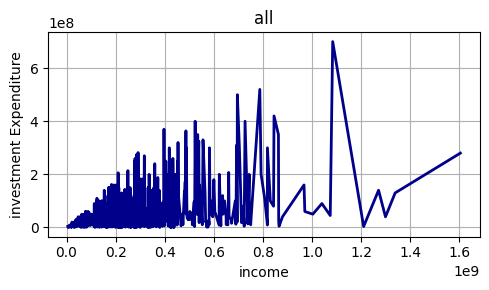

---------------1398---------------
---------------food-----------------


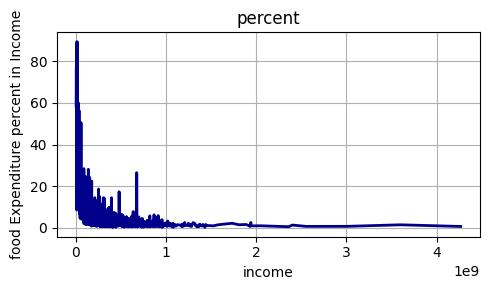

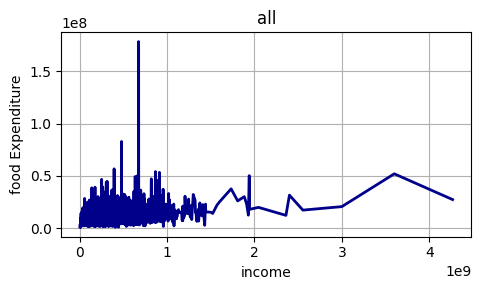

---------------tobacco-----------------


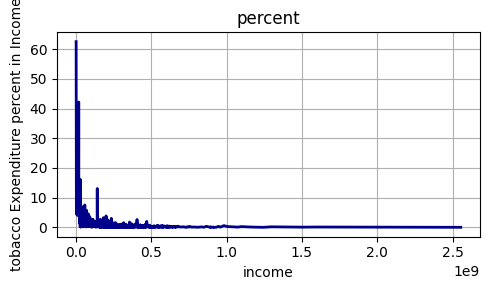

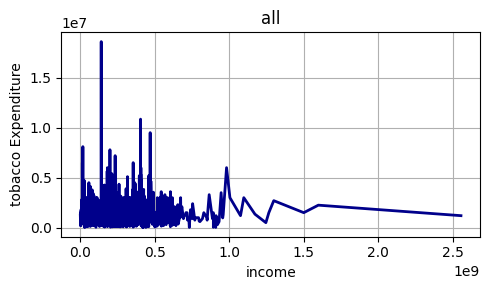

---------------cloth-----------------


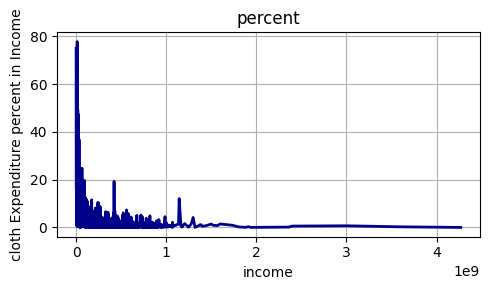

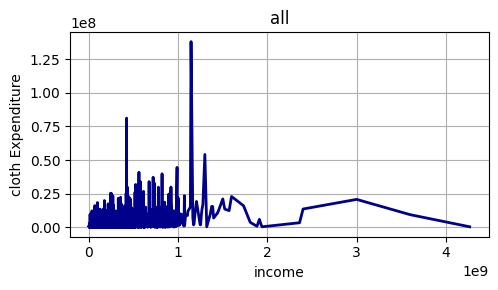

---------------home-----------------


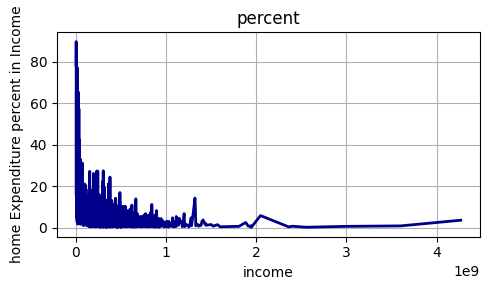

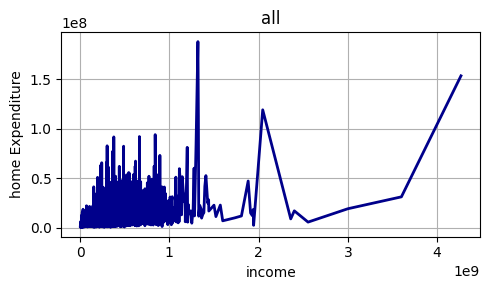

---------------furniture-----------------


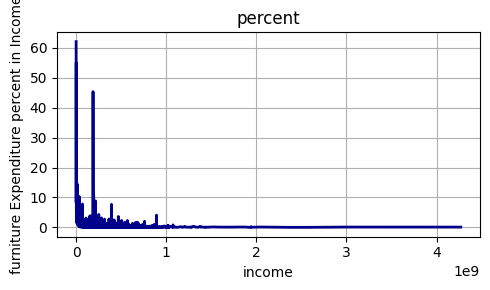

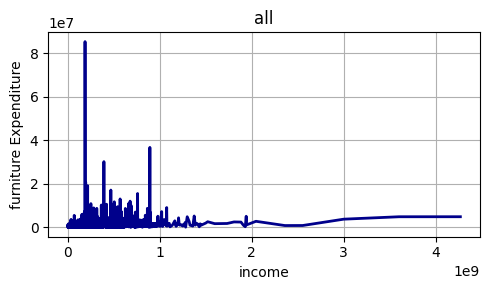

---------------medical-----------------


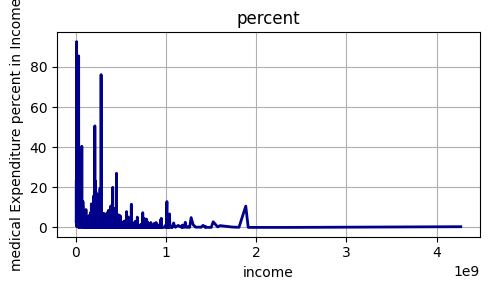

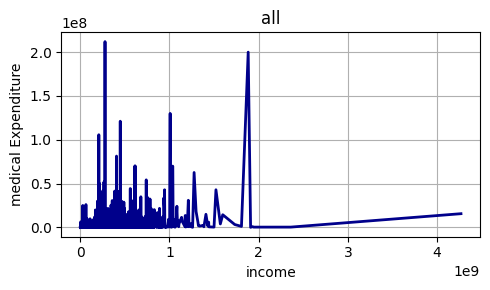

---------------transportation-----------------


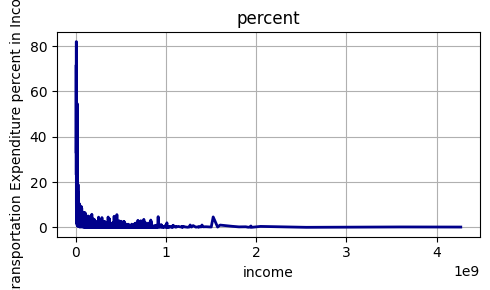

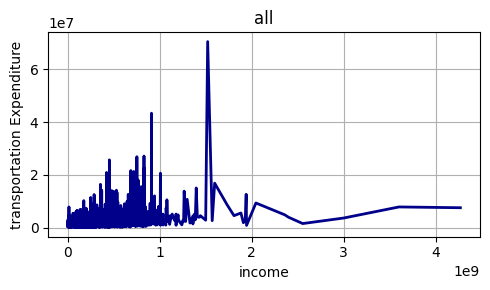

---------------communication-----------------


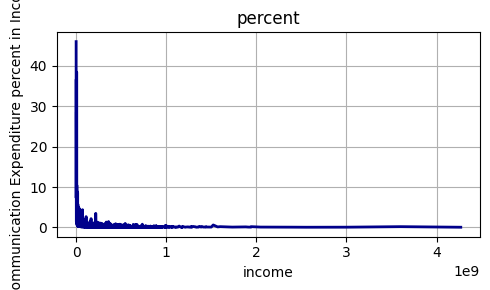

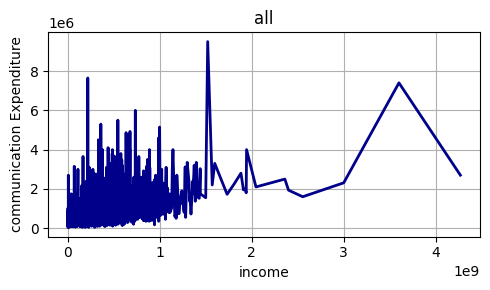

---------------entertainment-----------------


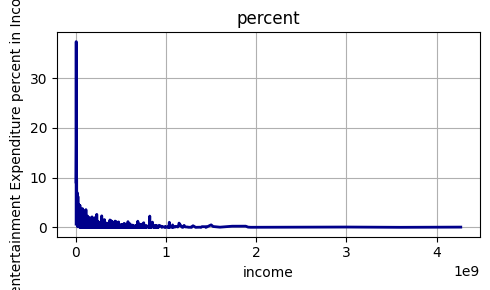

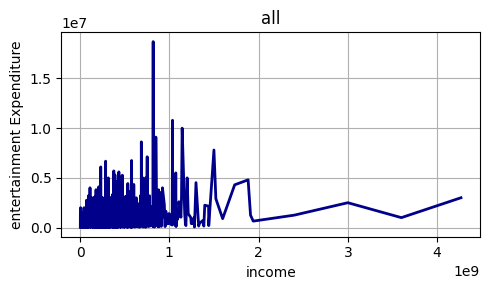

---------------hotel-----------------


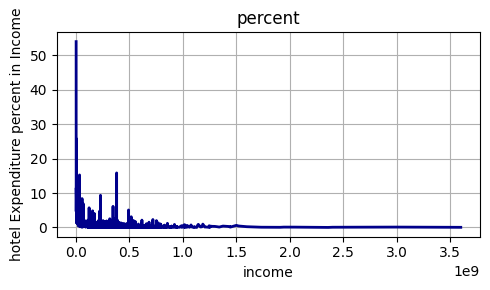

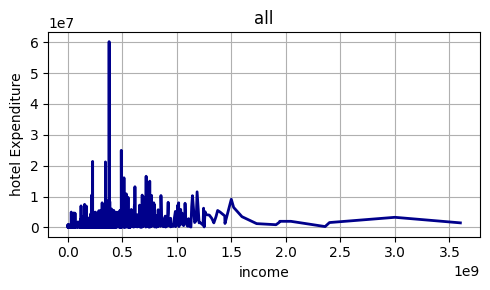

---------------miscellaneous-----------------


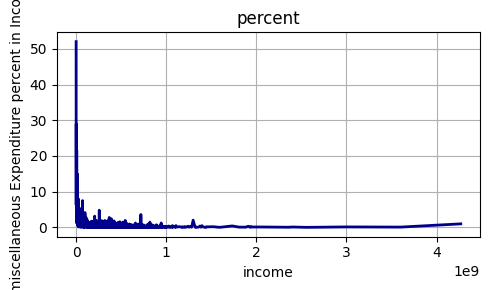

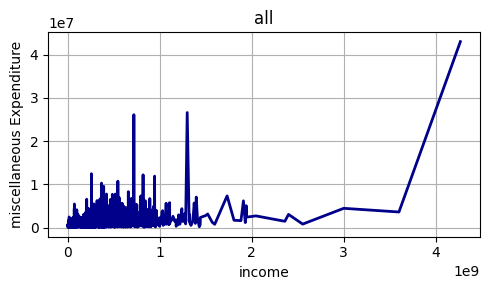

---------------durable-----------------


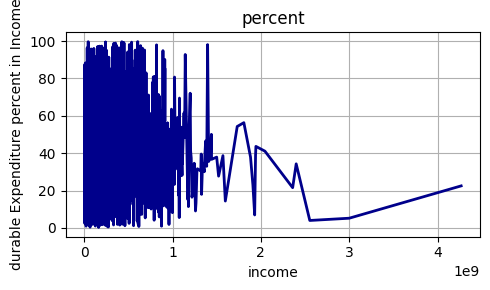

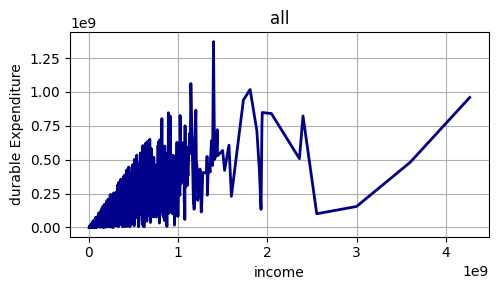

---------------investment-----------------


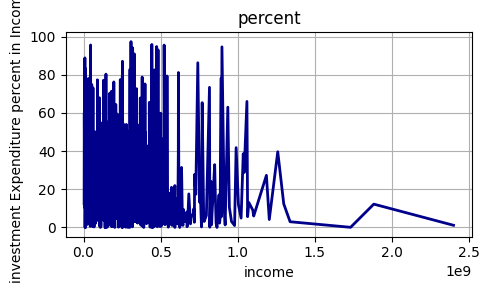

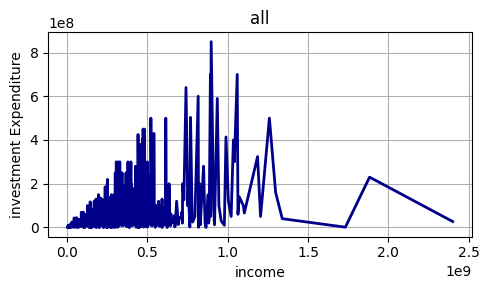

---------------1399---------------
---------------food-----------------


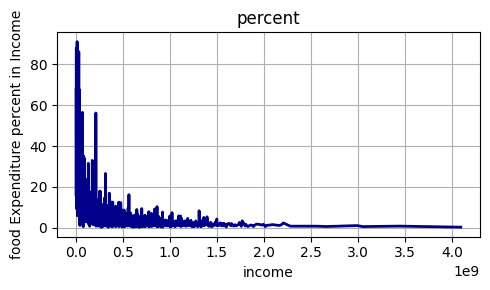

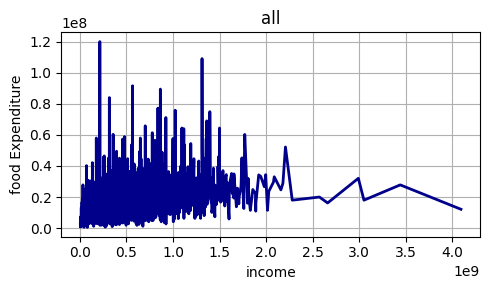

---------------tobacco-----------------


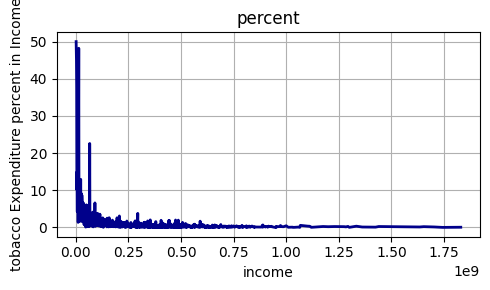

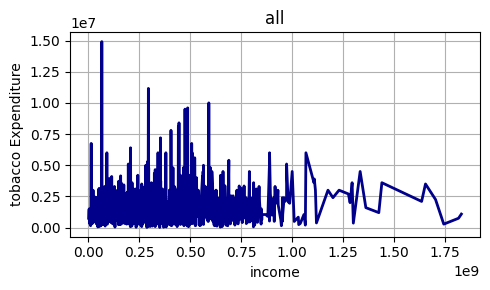

In [ ]:
for year in range(1395, 1402):
    print(f"---------------{year}---------------")
    food = csvfind("food",year)
    Tobacco = csvfind("tobacco",year)
    Cloth = csvfind("cloth",year)
    Home = csvfind("home",year)
    Furniture = csvfind("furniture",year)
    Medical = csvfind("medical",year)
    Transportation = csvfind("transportation",year)
    Communication = csvfind("communication",year)
    Entertainment= csvfind("entertainment",year)
    # Education = csvfind("education",year)
    Hotel = csvfind("hotel",year)
    Miscellaneous = csvfind("miscellaneous",year)
    Durable = csvfind("durable",year)
    Investment = csvfind("investment",year)
    employment_income = csvfind("employment_income",year)
    tables=[food,Tobacco,Cloth,Home,Furniture,Medical,Transportation,Communication,Entertainment,Hotel,Miscellaneous,Durable,Investment]
    employment_income = employment_income.groupby('ID').agg({'Annual_Net_Income': 'sum'}).reset_index()
    # for table in tables:
    for table in tables:
        try:
            result = employment_income
            result.rename(columns={'Annual_Net_Income':'Monthly_Income'},inplace=True)
            result['Monthly_Income'] = result['Monthly_Income']
            name = table['Table_Name'].loc[0]
            table['Expenditure'] = table['Expenditure'].fillna(0)
            table = table.groupby('ID').agg({'Expenditure': 'sum'}).reset_index()
            result = pd.merge(result, table, on="ID")
            result_main = result
            result_main = result_main[result_main['Expenditure'] < result_main['Monthly_Income']]
            result['Expenditure'] = result['Expenditure'] / result['Monthly_Income']
            result['Expenditure'] = result['Expenditure'] * 100
            result = result[result['Expenditure'] < 100]

        except Exception as e:
            print(f"<UNK> Error processing table {name}: {e}")
        print(f"---------------{name}-----------------")
        # for table in tables:
        result = result.groupby('Monthly_Income').agg({
            'Expenditure': 'mean'}).reset_index()
        plt.figure(figsize=(5, 3))
        plt.plot( result['Monthly_Income'],result['Expenditure'], color='darkblue', linewidth=2)
        plt.xlabel("income")
        plt.ylabel(f"{name} Expenditure percent in Income")
        plt.title("percent")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        result_main = result_main.groupby('Monthly_Income').agg({
            'Expenditure': 'mean'}).reset_index()
        plt.figure(figsize=(5, 3))
        plt.plot( result_main['Monthly_Income'],result_main['Expenditure'], color='darkblue', linewidth=2)
        plt.xlabel("income")
        plt.ylabel(f"{name} Expenditure")
        plt.title("all")
        plt.grid(True)
        plt.tight_layout()
        plt.show()